In [ ]:
%pip install torch

In [44]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import math

In [45]:
# обучение одной переменной
x = torch.tensor([5.0], requires_grad=True)
loss = (x - 3) ** 2
loss.backward()
print(f"Градиент loss по x: {x.grad.item()}")


Градиент loss по x: 4.0


In [46]:
# делаем шаг градиентного спуска
learning_rate = 0.1
x_new = x - learning_rate * x.grad
print(f"Было x = {x.item():.4f}")
print(f"Градиент = {x.grad.item():.4f}")
print(f"Стало x = {x_new.item():.4f}")

Было x = 5.0000
Градиент = 4.0000
Стало x = 4.6000


In [47]:
# сравниваем ошибки
new_loss = (x_new - 3) ** 2
print(f"Была ошибка = {loss.item():.4f}, стала = {new_loss.item():.4f}")

Была ошибка = 4.0000, стала = 2.5600


In [48]:
# цикл обучения (20 шагов)
x = torch.tensor([5.0], requires_grad=True)

for step in range(20):
    loss = (x - 3) ** 2
    
    if x.grad is not None:
        x.grad.zero_()  
    
    loss.backward()
    
    with torch.no_grad():  
        x -= 0.1 * x.grad
    
    if step % 5 == 0:
        print(f"Шаг {step}: x = {x.item():.4f}, ошибка = {loss.item():.4f}")

print(f"Финальное x = {x.item():.4f}")

Шаг 0: x = 4.6000, ошибка = 4.0000
Шаг 5: x = 3.5243, ошибка = 0.4295
Шаг 10: x = 3.1718, ошибка = 0.0461
Шаг 15: x = 3.0563, ошибка = 0.0050
Финальное x = 3.0231


In [49]:
# Создаем два параметра: вес w и смещение b
w = torch.tensor([2.0], requires_grad=True)
b = torch.tensor([1.0], requires_grad=True)

x_in = 5.0
y_pred = w * x_in + b
y_true = 15.0
loss = (y_pred - y_true) ** 2

loss.backward()

print(f"Градиент по w: {w.grad.item():.4f}")
print(f"Градиент по b: {b.grad.item():.4f}")

learning_rate = 0.01
with torch.no_grad():
    w -= learning_rate * w.grad
    b -= learning_rate * b.grad

print(f"Новый w = {w.item():.4f}, новый b = {b.item():.4f}")
print(f"Новый w = {w.item():.4f}, новый b = {b.item():.4f}")

Градиент по w: -40.0000
Градиент по b: -8.0000
Новый w = 2.4000, новый b = 1.0800
Новый w = 2.4000, новый b = 1.0800


In [50]:
# линейная регрессия (5 точек, ручное обновление) 
x_data = torch.tensor([0.0, 1.0, 2.0, 3.0, 4.0])
y_data = torch.tensor([1.2, 2.9, 5.1, 6.8, 9.0])

w = torch.tensor([0.0], requires_grad=True)
b = torch.tensor([0.0], requires_grad=True)

learning_rate = 0.01

for epoch in range(100):
    y_pred = w * x_data + b
    loss = ((y_pred - y_data) ** 2).mean()
    
    if w.grad is not None:
        w.grad.zero_()
        b.grad.zero_()
    
    loss.backward()
    
    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad
    
    if epoch % 20 == 0:
        print(f"Эпоха {epoch:3d}: w={w.item():.4f}, b={b.item():.4f}, ошибка={loss.item():.4f}")

print(f"\nИтог: w ≈ {w.item():.4f}, b ≈ {b.item():.4f}")

Эпоха   0: w=0.2780, b=0.1000, ошибка=32.6200
Эпоха  20: w=1.9633, b=0.7378, ошибка=0.1542
Эпоха  40: w=2.0460, b=0.8082, ошибка=0.0438
Эпоха  60: w=2.0399, b=0.8428, ошибка=0.0374
Эпоха  80: w=2.0300, b=0.8719, ошибка=0.0326

Итог: w ≈ 2.0214, b ≈ 0.8964


In [51]:
# Линейная регрессия с оптимизатором
x_data = torch.tensor([0.0, 1.0, 2.0, 3.0, 4.0])
y_data = torch.tensor([1.2, 2.9, 5.1, 6.8, 9.0])

w = torch.tensor([0.0], requires_grad=True)
b = torch.tensor([0.0], requires_grad=True)

optimizer = torch.optim.SGD([w, b], lr=0.01)

for epoch in range(100):
    y_pred = w * x_data + b
    loss = ((y_pred - y_data) ** 2).mean()
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if epoch % 20 == 0:
        print(f"Эпоха {epoch:3d}: w={w.item():.4f}, b={b.item():.4f}, ошибка={loss.item():.4f}")

Эпоха   0: w=0.2780, b=0.1000, ошибка=32.6200
Эпоха  20: w=1.9633, b=0.7378, ошибка=0.1542
Эпоха  40: w=2.0460, b=0.8082, ошибка=0.0438
Эпоха  60: w=2.0399, b=0.8428, ошибка=0.0374
Эпоха  80: w=2.0300, b=0.8719, ошибка=0.0326


In [52]:
# создание модели для функции от 2 переменных
# # определяем класс нейросети
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden1 = nn.Linear(2, 64)
        self.hidden2 = nn.Linear(64, 128)
        self.hidden3 = nn.Linear(128, 64)
        self.output = nn.Linear(64, 1)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.hidden1(x))
        x = self.relu(self.hidden2(x))
        x = self.relu(self.hidden3(x))
        x = self.output(x)
        return x

model = SimpleNet()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

In [53]:
# Генерация данных (20000 точек) и разделение на train/test/val
# Генерируем 20000 случайных точек от -10 до 10
n_samples = 20000
x_random = np.random.uniform(-10, 10, n_samples)
y_random = np.random.uniform(-10, 10, n_samples)

# Функция: sin(x + 2*y) * exp(-(2*x + y)^2)
z_data = np.sin(x_random + 2*y_random) * np.exp(-(2*x_random + y_random)**2)

# Превращаем в тензоры PyTorch
X = torch.FloatTensor(np.column_stack((x_random, y_random)))
y = torch.FloatTensor(z_data).reshape(-1, 1)

# Разделение 70% / 15% / 15%
n_train = int(0.7 * n_samples)   # 14000 точек
n_test = int(0.15 * n_samples)   # 3000 точек
n_val = n_samples - n_train - n_test  # 3000 точек

# Перемешиваем
indices = torch.randperm(n_samples)

X_train = X[indices[:n_train]]
y_train = y[indices[:n_train]]

X_test = X[indices[n_train:n_train + n_test]]
y_test = y[indices[n_train:n_train + n_test]]

X_val = X[indices[n_train + n_test:]]
y_val = y[indices[n_train + n_test:]]

print(f"Обучающая выборка (train): {len(X_train)} точек (70%)")
print(f"Тестовая выборка (test): {len(X_test)} точек (15%)")
print(f"Валидационная выборка (val): {len(X_val)} точек (15%)")

Обучающая выборка (train): 14000 точек (70%)
Тестовая выборка (test): 3000 точек (15%)
Валидационная выборка (val): 3000 точек (15%)


In [54]:
# обучение модели

for epoch in range(500):
    # Обучение
    model.train()
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Валидация
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val)
    
    if (epoch + 1) % 50 == 0:
        print(f"Эпоха {epoch+1:3d}: Train Loss = {loss.item():.6f}, Val Loss = {val_loss.item():.6f}")

Эпоха  50: Train Loss = 0.015865, Val Loss = 0.018205
Эпоха 100: Train Loss = 0.014676, Val Loss = 0.016514
Эпоха 150: Train Loss = 0.013547, Val Loss = 0.014891
Эпоха 200: Train Loss = 0.012460, Val Loss = 0.013584
Эпоха 250: Train Loss = 0.011500, Val Loss = 0.012549
Эпоха 300: Train Loss = 0.010649, Val Loss = 0.011603
Эпоха 350: Train Loss = 0.009864, Val Loss = 0.010705
Эпоха 400: Train Loss = 0.009192, Val Loss = 0.009875
Эпоха 450: Train Loss = 0.008513, Val Loss = 0.009052
Эпоха 500: Train Loss = 0.007572, Val Loss = 0.008002


In [55]:
# MSE на тестовой выборке
model.eval()
with torch.no_grad():
    test_pred = model(X_test)
    mse = criterion(test_pred, y_test).item()

print(f"MSE на тестовой выборке = {mse:.6f}")

MSE на тестовой выборке = 0.006277


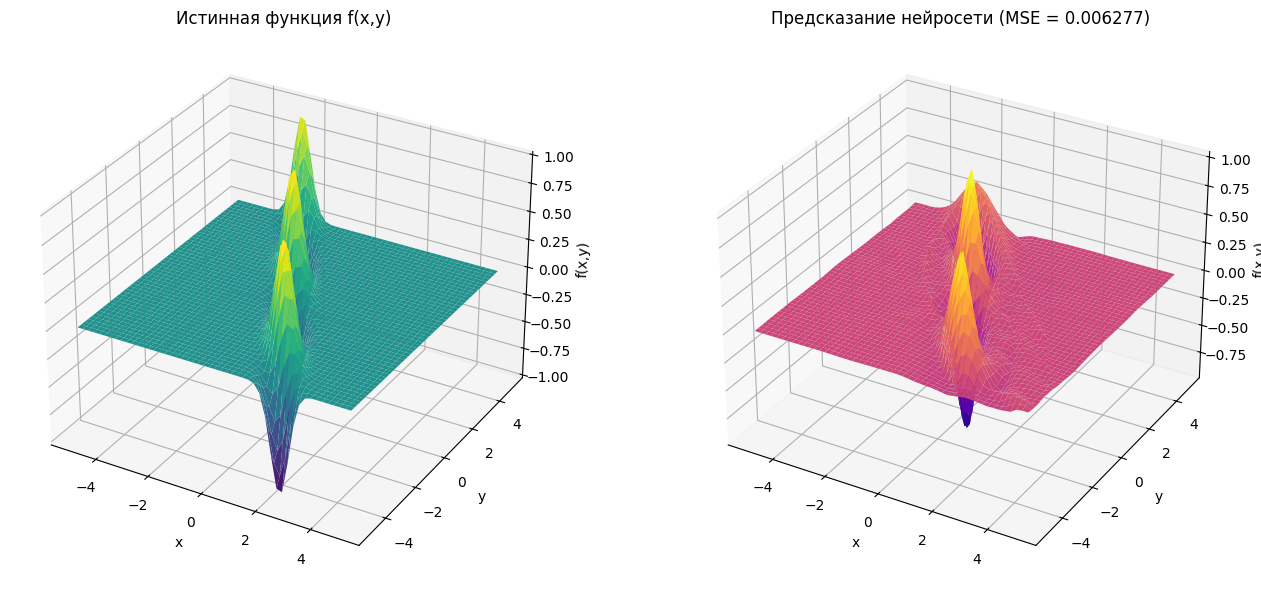

In [56]:
grid_size = 50
x_grid = np.linspace(-5, 5, grid_size)
y_grid = np.linspace(-5, 5, grid_size)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)

Z_true = np.sin(X_grid + 2*Y_grid) * np.exp(-(2*X_grid + Y_grid)**2)

Z_pred = np.zeros_like(X_grid)
with torch.no_grad():
    for i in range(grid_size):
        for j in range(grid_size):
            inp = torch.FloatTensor([[X_grid[i,j], Y_grid[i,j]]])
            Z_pred[i,j] = model(inp).item()

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X_grid, Y_grid, Z_true, cmap='viridis')
ax1.set_title('Истинная функция f(x,y)')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x,y)')

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X_grid, Y_grid, Z_pred, cmap='plasma')
ax2.set_title(f'Предсказание нейросети (MSE = {mse:.6f})')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('f(x,y)')

plt.tight_layout()
plt.show()

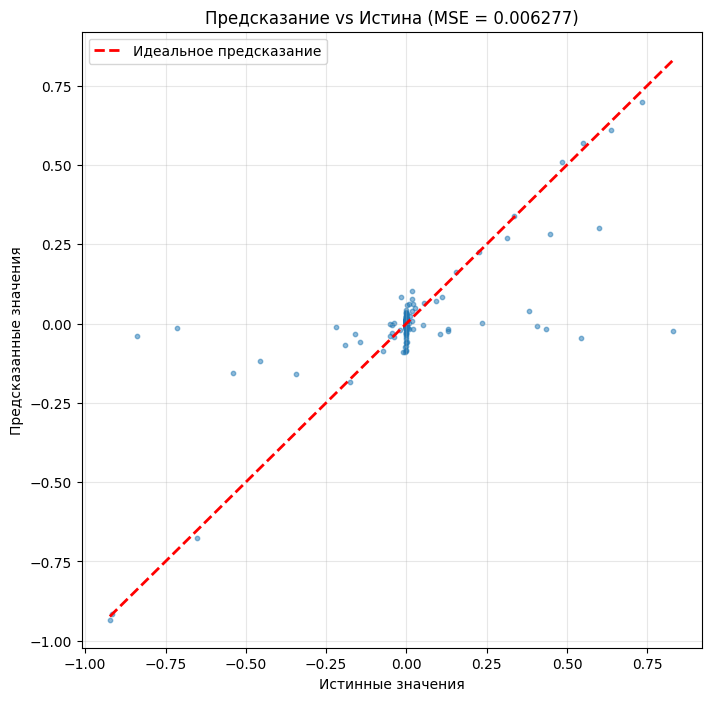

In [57]:
# дополнительный график "Предсказание vs Истина"
# берем случайные 500 точек из тестовой выборки для наглядности
n_show = 500
indices_show = torch.randperm(len(X_test))[:n_show]

X_show = X_test[indices_show]
y_true_show = y_test[indices_show]
y_pred_show = model(X_show)

plt.figure(figsize=(8, 8))
plt.scatter(y_true_show.numpy(), y_pred_show.detach().numpy(), alpha=0.5, s=10)
plt.plot([y_true_show.min().item(), y_true_show.max().item()], 
         [y_true_show.min().item(), y_true_show.max().item()], 
         'r--', linewidth=2, label='Идеальное предсказание')
plt.xlabel('Истинные значения')
plt.ylabel('Предсказанные значения')
plt.title(f'Предсказание vs Истина (MSE = {mse:.6f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [61]:
# дополнительные метрики
with torch.no_grad():
    predictions = model(X_test)
    errors = (predictions - y_test).abs()
    
    mae = errors.mean().item()  # Mean Absolute Error
    rmse = np.sqrt(mse)         # Root Mean Square Error
    max_error = errors.max().item()
    min_error = errors.min().item()

print("статистика на тестовой выборке:")
print(f"Mean Absolute Error (MAE):    {mae:.6f}")
print(f"Root Mean Square Error (RMSE): {rmse:.6f}")
print(f"Максимальная ошибка:          {max_error:.6f}")
print(f"Минимальная ошибка:           {min_error:.6f}")

статистика на тестовой выборке:
Mean Absolute Error (MAE):    0.018914
Root Mean Square Error (RMSE): 0.079228
Максимальная ошибка:          0.954492
Минимальная ошибка:           0.000000
